## Dynamic Pricing Algorithm

## Dynamic Pricing Algorithm Rules

The dynamic pricing algorithm adjusts class prices based on demand, session timing, location, and capacity utilization while maintaining customer satisfaction.

### Rule 1: Booking Rate
- Booking Rate ≥ 90% → Increase Price by **15%**
- Booking Rate 80–89% → Increase Price by **10%**
- Booking Rate 60–79% → Increase Price by **5%**
- Booking Rate < 40% → Decrease Price by **5%**

### Rule 2: Session
- Evening Session → Increase Price by **3%**
- Morning Session → Increase Price by **2%**

### Rule 3: Weekend
- Saturday & Sunday → Increase Price by **2%**

### Rule 4: High Demand Location
- Top 3 High-Demand Locations → Increase Price by **3%**

### Rule 5: Capacity Utilization
- If class occupancy is **95% or more**, increase price by **2%**

### Rule 6: Safety Rule
- Maximum Price Increase: **25%**
- Maximum Price Discount: **10%**

### Objective
- Increase revenue using demand-based pricing.
- Offer discounts during low demand.
- Prevent extreme price changes.
- Maintain customer satisfaction through safe pricing limits.

### Import necessary library

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load the Dataset

In [86]:
fitness_data = pd.read_excel("Cleaned_Preprocessed_Dataset_Yogeshwar Tribhuvan.xlsx")

### Create a New Price Column

In [87]:
fitness_data["NewPrice"] = fitness_data["Price (INR)"].astype(float)

### Convert Date Format

In [88]:
fitness_data["BookingEndDate"] = pd.to_datetime(fitness_data["BookingEndDate"])

fitness_data["DayName"] = fitness_data["BookingEndDate"].dt.day_name()

fitness_data["Hour"] = pd.to_datetime(
    fitness_data["BookingStartTime"].astype(str)
).dt.hour

### Create Session Feature

In [89]:
def session(hour):
    if hour < 12:
        return "Morning"
    elif hour < 17:
        return "Afternoon"
    else:
        return "Evening"

fitness_data["Session"] = fitness_data["Hour"].apply(session)

### Calculate Booking Rate

In [90]:
fitness_data["BookingRate"] = (
    fitness_data["Number Booked"] /
    fitness_data["MaxBookees"]
)

### Identify Weekend Classes

In [91]:
fitness_data["IsWeekend"] = fitness_data["DayName"].isin(
    ["Saturday", "Sunday"]
)

### Verify the Dataset

In [92]:
fitness_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3289 entries, 0 to 3288
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ActivitySiteID       3289 non-null   str           
 1   ActivityDescription  3289 non-null   str           
 2   BookingEndDate       3289 non-null   datetime64[us]
 3   BookingStartTime     3289 non-null   datetime64[us]
 4   MaxBookees           3289 non-null   int64         
 5   Number Booked        3289 non-null   int64         
 6   Price (INR)          3289 non-null   int64         
 7   NewPrice             3289 non-null   float64       
 8   DayName              3289 non-null   str           
 9   Hour                 3289 non-null   int32         
 10  Session              3289 non-null   str           
 11  BookingRate          3289 non-null   float64       
 12  IsWeekend            3289 non-null   bool          
dtypes: bool(1), datetime64[us](2), float64(2), i

### Apply Dynamic Pricing Rules

In [93]:
location_demand = (
    fitness_data
    .groupby("ActivitySiteID")["Number Booked"]
    .sum()
)

In [94]:
top_locations = (
    location_demand
    .sort_values(ascending=False)
    .head(3)
    .index
    .tolist()
)

print(top_locations)

['BRP', 'HXP', 'SBP']


In [95]:
def dynamic_price(row):

    price = row["Price (INR)"]
    multiplier = 1.0

    # =====================================
    # Rule 1 : Booking Rate (Highest Priority)
    # =====================================

    if row["BookingRate"] >= 0.90:
        multiplier += 0.15      # +15%

    elif row["BookingRate"] >= 0.80:
        multiplier += 0.10      # +10%

    elif row["BookingRate"] >= 0.60:
        multiplier += 0.05      # +5%

    elif row["BookingRate"] < 0.40:
        multiplier -= 0.05      # -5%


    # =====================================
    # Rule 2 : Session
    # =====================================

    if row["Session"] == "Evening":
        multiplier += 0.03

    elif row["Session"] == "Morning":
        multiplier += 0.02


    # =====================================
    # Rule 3 : Weekend
    # =====================================

    if row["IsWeekend"]:
        multiplier += 0.02


    # =====================================
    # Rule 4 : High Demand Location
    # =====================================

    if row["ActivitySiteID"] in top_locations:
        multiplier += 0.03


    # =====================================
    # Rule 5 : Capacity Utilization
    # =====================================

    if row["Number Booked"] >= row["MaxBookees"] * 0.95:
        multiplier += 0.02


    # =====================================
    # Rule 6 : Safety Rule
    # =====================================

    multiplier = min(max(multiplier, 0.90), 1.25)

    return round(price * multiplier, 2)
fitness_data["NewPrice"] = fitness_data.apply(dynamic_price, axis=1)

In [96]:
def expected_bookings(row):

    bookings = row["Number Booked"]

    if row["BookingRate"] >= 0.90:
        return bookings

    elif row["BookingRate"] >= 0.80:
        return bookings

    elif row["BookingRate"] >= 0.60:
        return bookings

    elif row["BookingRate"] >= 0.40:
        return round(bookings * 1.05)

    else:
        return round(bookings * 1.20)
fitness_data["ExpectedBookings"] = fitness_data.apply(
    expected_bookings,
    axis=1
)    

In [97]:
fitness_data["CurrentRevenue"] = (
    fitness_data["Price (INR)"] *
    fitness_data["Number Booked"]
)

fitness_data["ExpectedRevenue"] = (
    fitness_data["NewPrice"] *
    fitness_data["ExpectedBookings"]
)

fitness_data["RevenueGain"] = (
    fitness_data["ExpectedRevenue"] -
    fitness_data["CurrentRevenue"]
)

### Calculate Price Increase

In [98]:
fitness_data["PriceIncrease"] = (
    fitness_data["NewPrice"] -
    fitness_data["Price (INR)"]
)

### Display Updated Prices

In [104]:
fitness_data[
[
"ActivityDescription",
"ActivitySiteID",
"Session",
"Price (INR)",
"NewPrice",
"Number Booked",
"ExpectedBookings",
"CurrentRevenue",
"ExpectedRevenue",
"RevenueGain"
]
].head(20)

,ActivityDescription,ActivitySiteID,Session,Price (INR),NewPrice,Number Booked,ExpectedBookings,CurrentRevenue,ExpectedRevenue,RevenueGain
0,20-20-20 2.45pm-3.45pm,HXP,Afternoon,499,523.95,12,13,5988,6811.35,823.35
1,20-20-20 2.45pm-3.45pm,HXP,Afternoon,499,548.90,15,15,7485,8233.50,748.50
2,20-20-20 2.45pm-3.45pm,HXP,Afternoon,499,523.95,14,15,6986,7859.25,873.25
3,20-20-20 2.45pm-3.45pm,HXP,Afternoon,499,499.00,9,11,4491,5489.00,998.00
4,20-20-20 2.45pm-3.45pm,HXP,Afternoon,499,499.00,7,8,3493,3992.00,499.00
5,20-20-20 2.45pm-3.45pm,HXP,Afternoon,499,523.95,10,10,4990,5239.50,249.50
6,20-20-20 2.45pm-3.45pm,HXP,Afternoon,499,499.00,7,8,3493,3992.00,499.00
7,20-20-20 2.45pm-3.45pm,HXP,Afternoon,499,499.00,3,4,1497,1996.00,499.00
8,20-20-20 7.00-8.00pm,TSC,Evening,499,513.97,10,10,4990,5139.70,149.70
9,20-20-20 7.00-8.00pm,TSC,Evening,499,513.97,12,13,5988,6681.61,693.61


### Compare Average Prices

In [105]:
print("Original Average Price :",
      fitness_data["Price (INR)"].mean())

print("New Average Price :",
      fitness_data["NewPrice"].mean())

Original Average Price : 1850.231377318334
New Average Price : 1975.818929765886


### Visualize Price Comparison

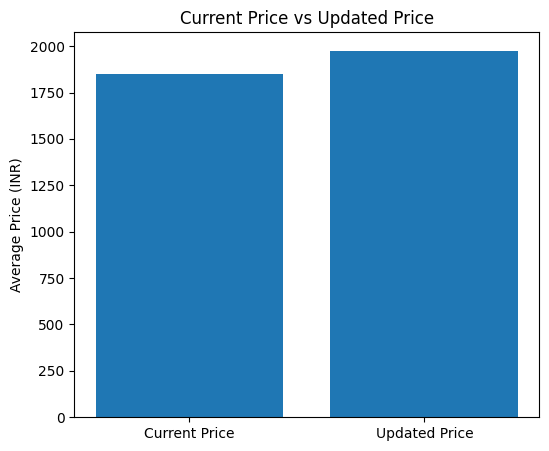

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    ["Current Price","Updated Price"],
    [
        fitness_data["Price (INR)"].mean(),
        fitness_data["NewPrice"].mean()
    ]
)

plt.title("Current Price vs Updated Price")
plt.ylabel("Average Price (INR)")
plt.show()

### View Final Dynamic Pricing Results

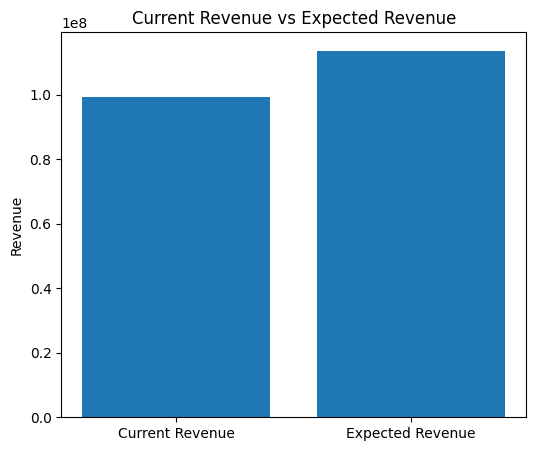

In [107]:
plt.figure(figsize=(6,5))

plt.bar(
    ["Current Revenue","Expected Revenue"],
    [
        fitness_data["CurrentRevenue"].sum(),
        fitness_data["ExpectedRevenue"].sum()
    ]
)

plt.title("Current Revenue vs Expected Revenue")
plt.ylabel("Revenue")
plt.show()

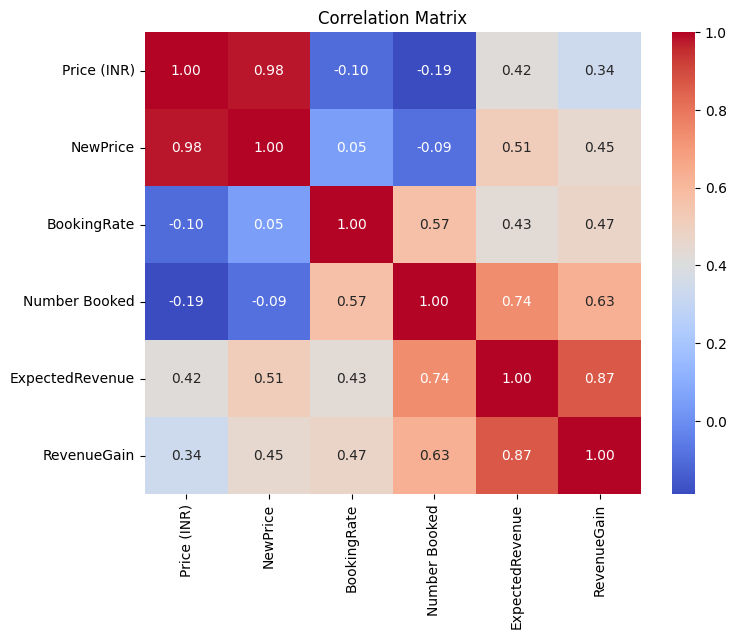

In [108]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    fitness_data[
    [
        "Price (INR)",
        "NewPrice",
        "BookingRate",
        "Number Booked",
        "ExpectedRevenue",
        "RevenueGain"
    ]
    ].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [110]:
current_revenue = fitness_data["CurrentRevenue"].sum()
expected_revenue = fitness_data["ExpectedRevenue"].sum()
revenue_gain = expected_revenue - current_revenue

growth_percent = (revenue_gain / current_revenue) * 100

print("========== Dynamic Pricing Summary ==========")
print(f"Current Revenue   : ₹{current_revenue:,.2f}")
print(f"Expected Revenue  : ₹{expected_revenue:,.2f}")
print(f"Revenue Gain      : ₹{revenue_gain:,.2f}")
print(f"Revenue Growth    : {growth_percent:.2f}%")

========== Dynamic Pricing Summary ==========
Current Revenue   : ₹99,333,795.00
Expected Revenue  : ₹113,640,409.89
Revenue Gain      : ₹14,306,614.89
Revenue Growth    : 14.40%


In [111]:
import pandas as pd

summary = pd.DataFrame({
    "Metric": [
        "Current Revenue",
        "Expected Revenue",
        "Revenue Gain",
        "Revenue Growth (%)"
    ],
    "Value": [
        current_revenue,
        expected_revenue,
        revenue_gain,
        growth_percent
    ]
})

summary

,Metric,Value
0,Current Revenue,9.933380e+07
1,Expected Revenue,1.136404e+08
2,Revenue Gain,1.430661e+07
3,Revenue Growth (%),1.440257e+01
